<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/CLT_CI_HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Viz Helpers

In [ ]:
# === DATA + PICTURE HELPERS — run this cell, then ignore it ========
COLORS = ["#2563eb", "#e07b39", "#3f9c7c"]

def load_uber(seed=11):
    "The same Uber ride file from Session 5 (simulated for teaching)."
    rng = np.random.default_rng(seed)
    slots = 24 * 30
    per_slot = rng.poisson(6, slots)
    hour_slot = np.repeat(np.arange(slots), per_slot)
    n = len(hour_slot)
    hour = hour_slot % 24
    peak = np.isin(hour, [8, 9, 10, 17, 18, 19])
    trip = np.clip(rng.normal(24, 6, n), 4, None).round(1)
    fare = 45 + 11 * trip + rng.normal(0, 25, n)
    surge = rng.random(n) < 0.02
    fare = np.where(surge, fare * rng.uniform(2.0, 2.8, n), fare)
    cancelled = (rng.random(n) < np.where(peak, 0.20, 0.08)).astype(int)
    fraud = (rng.random(n) < 0.01).astype(int)
    flagged = (rng.random(n) < np.where(fraud == 1, 0.90, 0.05)).astype(int)
    return pd.DataFrame({
        "hour_slot": hour_slot, "hour": hour, "is_peak": peak.astype(int),
        "trip_minutes": trip, "fare": fare.round(2), "surge": surge.astype(int),
        "cancelled": cancelled, "is_fraud": fraud, "flagged": flagged})

def _axes(title, xlabel, ylabel, size=(6, 4)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color="#e8e8e8"); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return ax

def show_hist(values, title, xlabel, marks=None, bins=40):
    ax = _axes(title, xlabel, "how often")
    ax.hist(values, bins=bins, color=COLORS[0], alpha=0.85)
    for i, (name, v) in enumerate((marks or {}).items()):
        ax.axvline(v, color=COLORS[i % 2 + 1], lw=2, ls="--")
        ax.annotate(f"{name} = {v:.2f}", (v, ax.get_ylim()[1] * (0.92 - 0.1 * i)),
                    xytext=(9, 0), textcoords="offset points",
                    color=COLORS[i % 2 + 1], fontsize=9)
    plt.show()

def show_line(x, y, title, xlabel, ylabel):
    ax = _axes(title, xlabel, ylabel)
    ax.plot(x, y, "o-", color=COLORS[0], ms=6, lw=1.5)
    for xi, yi in zip(x, y):
        ax.annotate(f"{yi:.2f}", (xi, yi), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=9)
    ax.margins(y=0.20); plt.show()

def show_intervals(lows, highs, truth, title):
    "One horizontal line per confidence interval; red ones missed the truth."
    ax = _axes(title, "average trip minutes", "one interval per sample", (6, 5))
    for i, (lo, hi) in enumerate(zip(lows, highs)):
        hit = lo <= truth <= hi
        ax.plot([lo, hi], [i, i], color=COLORS[0] if hit else COLORS[1],
                lw=1.2, alpha=0.9 if hit else 1)
    ax.axvline(truth, color="#333333", lw=2)
    ax.annotate(f"the truth = {truth:.2f}", (truth, len(lows) * 0.98),
                xytext=(8, 0), textcoords="offset points", fontsize=9)
    ax.set_yticks([]); ax.grid(False); plt.show()


## Population vs Sample

In [ ]:
rides = load_uber()
print("full Uber ride file loaded:", len(rides), "rides")

full Uber ride file loaded: 4328 rides


In [ ]:
rides.head()

,hour_slot,hour,is_peak,trip_minutes,fare,surge,cancelled,is_fraud,flagged
0,0,0,0,30.6,425.04,0,0,0,0
1,0,0,0,27.7,326.40,0,0,0,0
2,0,0,0,23.8,281.49,0,0,0,0
3,1,1,0,16.0,253.05,0,0,0,0
4,1,1,0,21.3,305.81,0,0,0,0


The average trip takes 25 minutes.

In [ ]:
population = rides["trip_minutes"]

print("population size:", len(population), "rides")
print("TRUE average trip:", round(population.mean(), 2), "minutes")
print("TRUE spread (std):", round(population.std(), 2), "minutes")

population size: 4328 rides
TRUE average trip: 24.12 minutes
TRUE spread (std): 6.08 minutes


### Sampling

In [ ]:
sample = population.sample(200, random_state=42)     # 200 rides, chosen at random

print("sample size:", len(sample))
print("sample average trip:", round(sample.mean(), 2), "minutes")

sample size: 200
sample average trip: 24.05 minutes


In [ ]:
population.sample(200, random_state=7).mean()

np.float64(23.664499999999997)

## Sampling Variability

In [ ]:
for seed in [1, 2, 3]:
    s = population.sample(100, random_state=seed)
    print("sample", seed, "-> average trip:", round(s.mean(), 2), "minutes")

sample 1 -> average trip: 24.4 minutes
sample 2 -> average trip: 25.06 minutes
sample 3 -> average trip: 24.19 minutes


1. Take three samples of size **20** from `population` (use `random_state=1,2,3`)
   and print `fare` means. How spread out are they?
2. Now take three samples of size **500`** and print those means.

In [ ]:
rides['fare'].sample(20).mean().round(2)

np.float64(335.91)

In [ ]:
rides['fare'].sample(20).mean().round(2)

np.float64(338.74)

In [ ]:
rides['fare'].sample(20).mean().round(2)

np.float64(320.52)

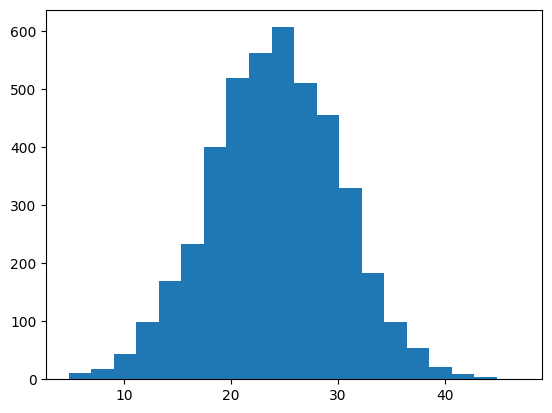

In [ ]:
plt.hist(rides['trip_minutes'], bins=20);

In [ ]:
duration_sample_means = []
for _ in range(100):
    m = population.sample(20).mean().round(2)
    duration_sample_means.append(m)

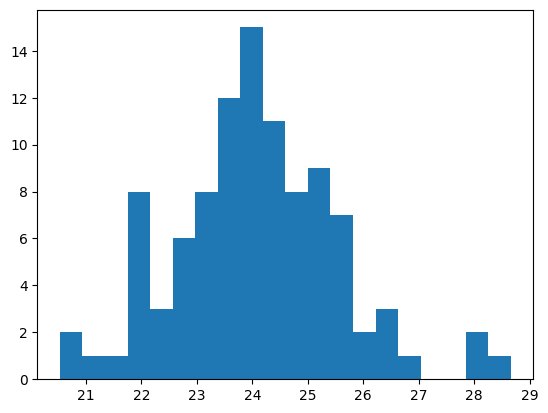

In [ ]:
plt.hist(duration_sample_means, bins = 20);

## CLT

population fare — skew: 2.64  <- heavily right-skewed


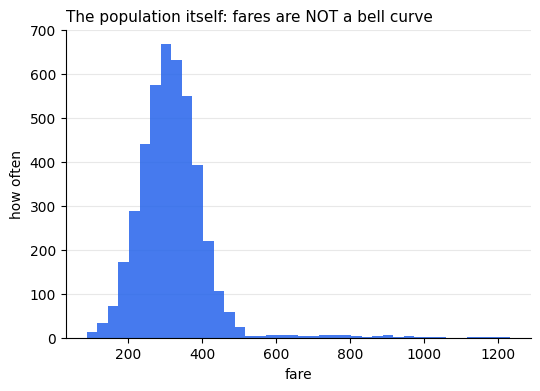

In [ ]:
print("population fare — skew:", round(rides["fare"].skew(), 2), " <- heavily right-skewed")

show_hist(rides["fare"], "The population itself: fares are NOT a bell curve", "fare")

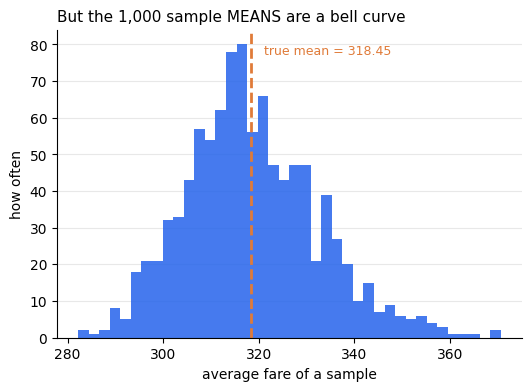

In [ ]:
sample_means = [rides["fare"].sample(50, random_state=i).mean() for i in range(1000)]

show_hist(sample_means, "But the 1,000 sample MEANS are a bell curve", "average fare of a sample",
          marks={"true mean": rides["fare"].mean()})

In [ ]:
print("population skew   :", round(rides["fare"].skew(), 2))
print("sample-means skew :", round(pd.Series(sample_means).skew(), 2), " <- the proves it's symmetrical/normal")
print()

population skew   : 2.64
sample-means skew : 0.46  <- the proves it's symmetrical/normal



In [ ]:
# we have calculated......
np.mean(sample_means)

np.float64(318.532646)

In [ ]:
# population mean
rides['fare'].mean().round(2)

np.float64(318.45)

> **Take samples and average them, and those averages form a Normal
> distribution centred on the true population mean — even when the population
> itself is nothing like Normal.**

In [ ]:
np.std(sample_means) * np.sqrt(50)

np.float64(98.47541718950065)

In [ ]:
rides['fare'].std()

97.91248362128991

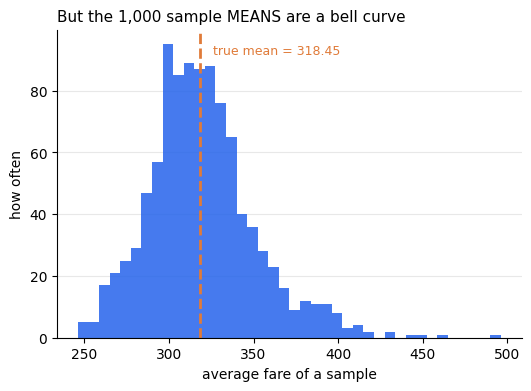

np.float64(31.911644614371962)

In [ ]:
sample_means = [rides["fare"].sample(10, random_state=i).mean() for i in range(1000)]

show_hist(sample_means, "But the 1,000 sample MEANS are a bell curve", "average fare of a sample",
          marks={"true mean": rides["fare"].mean()})
np.std(sample_means)

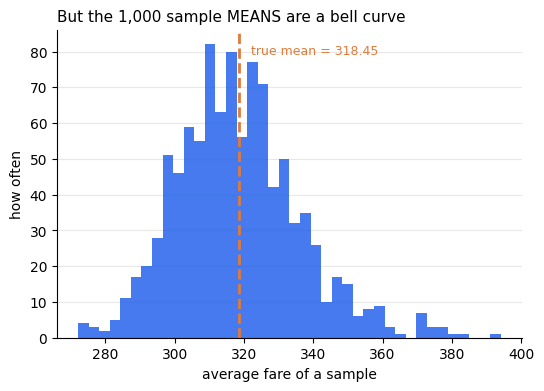

np.float64(17.875582525833003)

In [ ]:
sample_means = [rides["fare"].sample(30, random_state=i).mean() for i in range(1000)]

show_hist(sample_means, "But the 1,000 sample MEANS are a bell curve", "average fare of a sample",
          marks={"true mean": rides["fare"].mean()})
np.std(sample_means)

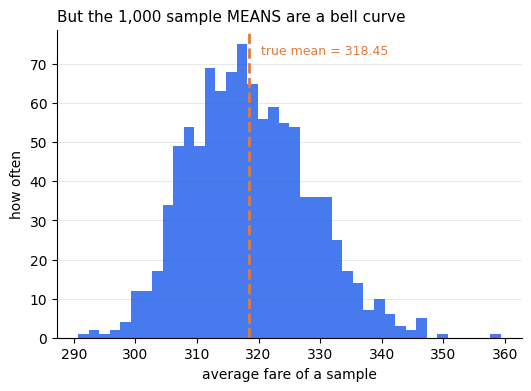

np.float64(9.720536864898941)

In [ ]:
sample_means = [rides["fare"].sample(100, random_state=i).mean() for i in range(1000)]

show_hist(sample_means, "But the 1,000 sample MEANS are a bell curve", "average fare of a sample",
          marks={"true mean": rides["fare"].mean()})
np.std(sample_means)

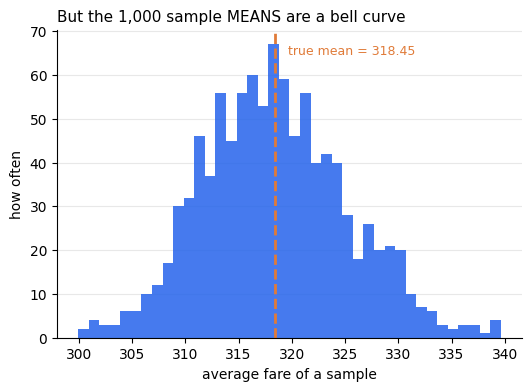

np.float64(6.789853904490198)

In [ ]:
sample_means = [rides["fare"].sample(200, random_state=i).mean() for i in range(1000)]

show_hist(sample_means, "But the 1,000 sample MEANS are a bell curve", "average fare of a sample",
          marks={"true mean": rides["fare"].mean()})
np.std(sample_means)

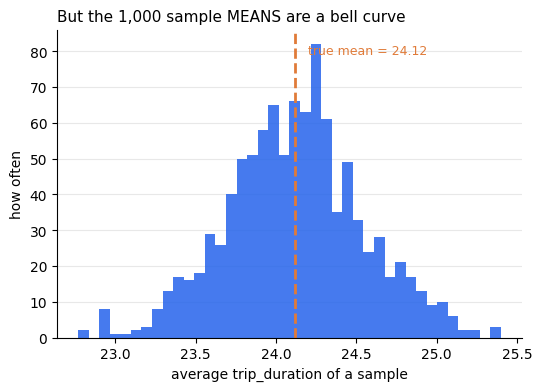

In [ ]:
sample_means = [rides["trip_minutes"].sample(200, random_state=i).mean() for i in range(1000)]

show_hist(sample_means, "But the 1,000 sample MEANS are a bell curve", "average trip_duration of a sample",
          marks={"true mean": rides["trip_minutes"].mean()})

In [ ]:
mu = np.mean(sample_means)
se = np.std(sample_means)
print("mu:", mu)
print("se:", se)


mu: 24.118503
se: 0.4273602005229311


In [ ]:
low = mu - 2*se
high= mu + 2*se

print("95% confidence interval: [", round(low, 2), ",", round(high, 2), "]")

95% confidence interval: [ 23.26 , 24.97 ]


In [ ]:
population.mean()

np.float64(24.120702402957484)

intervals that captured the true mean: 96 out of 100


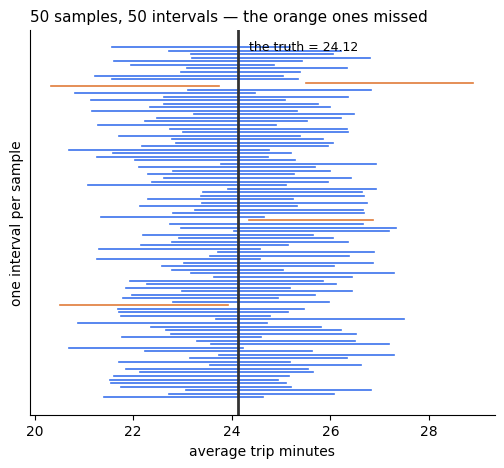

In [ ]:
lows, highs = [], []
for i in range(100):
    s = population.sample(50, random_state=i)
    e = s.std() / np.sqrt(50)
    lows.append(s.mean() - 2 * e)
    highs.append(s.mean() + 2 * e)

captured = sum(lo <= population.mean() <= hi for lo, hi in zip(lows, highs))
print("intervals that captured the true mean:", captured, "out of 100")

show_intervals(lows, highs, population.mean(),
               "50 samples, 50 intervals — the orange ones missed")

1. Build a 95% confidence interval for `rides["fare"]` from a sample of 100
2. Does it contain the true mean fare (`rides["fare"].mean()`)?
3. Rebuild it with a sample of 400. Is the interval wider or narrower — and why?

In [ ]:
sample_means = [rides["fare"].sample(100, random_state=i).mean() for i in range(1000)]
mu = np.mean(sample_means)
se = np.std(sample_means)

print(f"[{mu-2*se}, {mu+2*se}]")

[299.1658254702021, 338.0479729297979]


In [ ]:
# rides['fare'].mean()

In [ ]:
sample_means = [rides["fare"].sample(400, random_state=i).mean() for i in range(1000)]
mu = np.mean(sample_means)
se = np.std(sample_means)

print(f"[{mu-2*se}, {mu+2*se}]")

[309.5174632008994, 327.55532289910053]


## Hypothesis Testing
-  Uber promise:  the average trip takes 25 minutes.


Hypothese: the average trip takes less than 25 mins. (mu<25)


H0 : the average trip atlest takes 25 minutes.  (μ ≥ 25)

H1 : the average trip is less than 25 minutes. (μ < 25)

In [ ]:
claim = 25.0
sample = population.sample(200, random_state=42)

se = sample.std() / np.sqrt(200)

z = (sample.mean() - claim)/ se
print("sample mean    :", round(sample.mean(), 2))
print("claim          :", claim)
print("standard error :", round(se, 3))
print("z =", round(z, 2))

sample mean    : 24.05
claim          : 25.0
standard error : 0.414
z = -2.29


In [ ]:
p_value = stats.norm.cdf(z)
print(p_value)

0.01094058147775821


In [ ]:
alpha = 0.05
decision = "REJECT H0" if p_value < alpha else "fail to reject H0"
print(f"alpha = {alpha}  ->  p={p_value:.4f}  ->  {decision}")

alpha = 0.05  ->  p=0.0109  ->  REJECT H0


In [ ]:
from statsmodels.stats.weightstats import ztest

z_stat, p_val = ztest(sample, value=25.0, alternative="smaller")  # H1 : mu < 25

In [ ]:
z_stat

np.float64(-2.292424441972445)

In [ ]:
p_val

np.float64(0.010940581477758197)

## Type I and Type II Errors

In [ ]:
# URL Shortner.